<a href="https://colab.research.google.com/github/srijasriramdas/DL/blob/main/DeepLearningLab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

week1

In [ ]:
#Build a Simple Neural Network with PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# XOR dataset
X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
y = torch.tensor([[0.],[1.],[1.],[0.]])

# Model
model = nn.Sequential(
    nn.Linear(2,4),
    nn.Sigmoid(),
    nn.Linear(4,1),
    nn.Sigmoid()
)

loss = nn.BCELoss()
opt = optim.SGD(model.parameters(), lr=0.1)

# Training
for i in range(2000):
    out = model(X)
    l = loss(out, y)

    opt.zero_grad()
    l.backward()
    opt.step()

print(model(X))

tensor([[0.5008],
        [0.4817],
        [0.5234],
        [0.4898]], grad_fn=<SigmoidBackward0>)


In [ ]:
# Simple Neural Network with TensorFlow
import tensorflow as tf
import numpy as np

# Sample data
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y = np.array([[0],[1],[1],[0]], dtype=float)

# Model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='sigmoid', input_shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='sgd',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X, y, epochs=2000, verbose=0)

print("Predictions:")
print(model.predict(X))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Predictions:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
[[0.4924252 ]
 [0.50659025]
 [0.49681783]
 [0.5109702 ]]


In [ ]:
#keras
from tensorflow import keras
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])

model = keras.Sequential()

model.add(keras.layers.Dense(4, input_dim=2, activation='relu'))
model.add(keras.layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X, y, epochs=500, verbose=0)

print(model.predict(X))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
[[0.5045967 ]
 [0.5625356 ]
 [0.51370007]
 [0.46661556]]


In [ ]:
# Simple perceptron
import numpy as np

# Input dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,0,0,1])  # AND gate

# Initialize weights and bias
w = np.random.rand(2)
b = np.random.rand()

lr = 0.1

def step(x):
    return 1 if x >= 0 else 0

# Training
for epoch in range(10):
    for i in range(len(X)):
        z = np.dot(X[i], w) + b
        y_pred = step(z)

        error = y[i] - y_pred

        w += lr * error * X[i]
        b += lr * error

print("Weights:", w)
print("Bias:", b)

Weights: [0.431915   0.40440469]
Bias: -0.5270531342589322




---



week2

In [ ]:
# Single Perceptron for AND and OR

def perceptron(x1, x2, w1, w2, b):
    z = x1*w1 + x2*w2 + b
    if z >= 0:
        return 1
    else:
        return 0

inputs = [(0,0),(0,1),(1,0),(1,1)]

print("AND Gate")
for x1,x2 in inputs:
    y = perceptron(x1,x2,1,1,-1.5)
    print(x1,x2,"->",y)

print("\nOR Gate")
for x1,x2 in inputs:
    y = perceptron(x1,x2,1,1,-0.5)
    print(x1,x2,"->",y)

AND Gate
0 0 -> 0
0 1 -> 0
1 0 -> 0
1 1 -> 1

OR Gate
0 0 -> 0
0 1 -> 1
1 0 -> 1
1 1 -> 1


In [ ]:
# XOR using Multi Layer Perceptron

def step(x):
    return 1 if x>=0 else 0

def perceptron(x1,x2,w1,w2,b):
    return step(x1*w1 + x2*w2 + b)

inputs = [(0,0),(0,1),(1,0),(1,1)]

print("XOR using multi perceptron")

for x1,x2 in inputs:

    h2 = perceptron(x1,x2,1,1,-1.5)     # AND
    h1 = perceptron(x1,x2,1,1,-0.5)     # OR

    y = perceptron(h1,h2,1, -2, -0.5)
    not_xor = perceptron(y, 0, -1, 0, 0.5)


    print(x1,x2,"->",y, not_xor)

XOR using multi perceptron
0 0 -> 0 1
0 1 -> 1 0
1 0 -> 1 0
1 1 -> 0 1


In [ ]:
#demosntrate harsh thresholding
def step(x):
    if x>=0:
        return 1
    else:
        return 0

values = [-0.01,0,0.01]

for v in values:
    print(v,"->",step(v))

-0.01 -> 0
0 -> 1
0.01 -> 1


In [ ]:
import numpy as np

X = np.array([
    [1,1,1,0.9],
    [1,0,0,0.7],
    [0,1,0,0.6],
    [0,0,1,0.4],
    [1,1,0,0.8],
    [0,0,0,0.3]
])

y = np.array([1,1,0,0,1,0])

w = np.zeros(4)
b = 0
lr = 0.1

for epoch in range(10):
    for i in range(len(X)):
        z = np.dot(X[i], w) + b
        pred = 1 if z >= 0 else 0
        err = y[i] - pred

        w += lr * err * X[i]
        b += lr * err

print("Weights:", w)
print("Bias:", b)

test = np.array([1,1,0,0.85])

z = np.dot(test, w) + b
print("LIKE" if z >= 0 else "DISLIKE")

Weights: [3.00000000e-01 0.00000000e+00 0.00000000e+00 4.16333634e-17]
Bias: -0.2
LIKE


In [ ]:
#representation power of neurons
import numpy as np
import itertools

# input dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])

def train_perceptron(y):

    w = np.zeros(2)
    b = 0
    lr = 0.1

    for epoch in range(20):
        error_count = 0

        for i in range(len(X)):
            z = np.dot(X[i],w) + b
            y_pred = 1 if z>=0 else 0

            error = y[i] - y_pred

            if error != 0:
                error_count += 1

            w = w + lr * error * X[i]
            b = b + lr * error

        if error_count == 0:
            return True

    return False


# generate all 16 boolean functions
functions = list(itertools.product([0,1], repeat=4))

learnable = 0
not_learnable = 0

for f in functions:
    y = np.array(f)

    if train_perceptron(y):
        learnable += 1
    else:
        not_learnable += 1

print("Learnable functions:",learnable)
print("Not learnable functions:",not_learnable)

Learnable functions: 14
Not learnable functions: 2


In [ ]:
#multi-layer perceptron architecture
import numpy as np

def step(x):
    return 1 if x >= 0 else 0


# hidden perceptrons
def h1(x1,x2):
    return step(-x1 -x2 + 0.5)   # detects (0,0)

def h2(x1,x2):
    return step(-x1 +x2 -0.5)    # detects (0,1)

def h3(x1,x2):
    return step(x1 -x2 -0.5)     # detects (1,0)

def h4(x1,x2):
    return step(x1 +x2 -1.5)     # detects (1,1)


# MLP output neuron
def mlp(x1,x2,w):

    H1 = h1(x1,x2)
    H2 = h2(x1,x2)
    H3 = h3(x1,x2)
    H4 = h4(x1,x2)

    z = w[0]*H1 + w[1]*H2 + w[2]*H3 + w[3]*H4 - 0.5

    return step(z)


# Example Boolean Function: XOR
weights = [0,1,1,0]

inputs = [(0,0),(0,1),(1,0),(1,1)]

print("XOR Output")

for x1,x2 in inputs:
    print(x1,x2,"->",mlp(x1,x2,weights))

XOR Output
0 0 -> 0
0 1 -> 1
1 0 -> 1
1 1 -> 0


In [ ]:
#three binary inputs
import numpy as np

def step(x):
    return 1 if x >= 0 else 0


def hidden_layer(x1,x2,x3):

    h1 = step(-x1 -x2 -x3 +0.5)
    h2 = step(-x1 -x2 +x3 -0.5)
    h3 = step(-x1 +x2 -x3 -0.5)
    h4 = step(-x1 +x2 +x3 -1.5)
    h5 = step(x1 -x2 -x3 -0.5)
    h6 = step(x1 -x2 +x3 -1.5)
    h7 = step(x1 +x2 -x3 -1.5)
    h8 = step(x1 +x2 +x3 -2.5)

    return [h1,h2,h3,h4,h5,h6,h7,h8]


def mlp(x1,x2,x3,weights):

    h = hidden_layer(x1,x2,x3)

    z = sum(w*h_i for w,h_i in zip(weights,h)) - 0.5

    return step(z)


inputs = [
(0,0,0),
(0,0,1),
(0,1,0),
(0,1,1),
(1,0,0),
(1,0,1),
(1,1,0),
(1,1,1)
]

# example boolean function weights
weights = [0,1,0,1,1,0,1,0]

for x1,x2,x3 in inputs:
    print(x1,x2,x3,"->",mlp(x1,x2,x3,weights))

0 0 0 -> 0
0 0 1 -> 1
0 1 0 -> 0
0 1 1 -> 1
1 0 0 -> 1
1 0 1 -> 0
1 1 0 -> 1
1 1 1 -> 0




---



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Learning Rates: [0.0001, 0.001, 0.01, 0.1]
Loss: [1.0154008629547067, 0.27045766209346384, 0.3226020114232832, 0.40021102704076833]


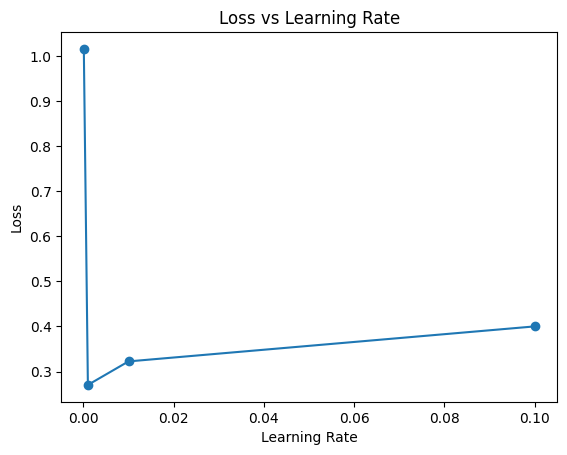

In [ ]:
#MLP with diff learning rates and epochs
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss

# dataset
X, y = make_classification(n_samples=500, n_features=10, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

learning_rates = [0.0001,0.001,0.01,0.1]
loss_values = []

for lr in learning_rates:

    model = MLPClassifier(hidden_layer_sizes=(5,),
                          learning_rate_init=lr,
                          max_iter=500,
                          random_state=42)

    model.fit(X_train,y_train)

    y_pred_prob = model.predict_proba(X_test)

    loss = log_loss(y_test,y_pred_prob)

    loss_values.append(loss)

print("Learning Rates:",learning_rates)
print("Loss:",loss_values)

plt.plot(learning_rates,loss_values,marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Loss vs Learning Rate")
plt.show()

In [ ]:
# MLP using Gradient Descent
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = load_breast_cancer()

X_train,X_test,y_train,y_test = train_test_split(data.data,data.target,test_size=0.2)

model = MLPClassifier(hidden_layer_sizes=(10,5),
                      solver='sgd',     # gradient descent
                      learning_rate_init=0.01,
                      max_iter=500)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.6403508771929824


In [ ]:
# Perceptron on IRIS Dataset
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
iris = load_iris()

X_train,X_test,y_train,y_test = train_test_split(iris.data,iris.target,test_size=0.2)

model = Perceptron(
    max_iter=1000,
    eta0=0.01,
    random_state=42
)
model2 = MLPClassifier(hidden_layer_sizes = (10,5),
                       learning_rate_init = 0.01,
                       max_iter = 500,
                       random_state = 42)
model.fit(X_train,y_train)
model2.fit(X_train,y_train)

pred = model.predict(X_test)
pred2 = model2.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))
print("Accuracy:",accuracy_score(y_test,pred2))

Accuracy: 0.4666666666666667
Accuracy: 0.9


In [ ]:
# MLP on Wine Dataset
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

data = load_wine()

X_train,X_test,y_train,y_test = train_test_split(data.data,data.target,test_size=0.2)

model = MLPClassifier(
        hidden_layer_sizes=(20,10),
        learning_rate_init=0.01,
        max_iter=500,
        activation='relu'
)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.4444444444444444


In [ ]:
#handwritten digit (MNIST)
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

digits = load_digits()

X_train,X_test,y_train,y_test = train_test_split(
    digits.data,
    digits.target,
    test_size=0.2
)

model = MLPClassifier(
        hidden_layer_sizes=(128,128),
        learning_rate_init=0.001,
        max_iter=500,
        activation='relu'
)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.9861111111111112




---



In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta

# XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

batches = {"BGD":4, "SGD":1, "MiniBatch":2}

for gd, batch in batches.items():
    print("\n", gd)

    optimizers = {
        "SGD": SGD(learning_rate=0.1),
        "Momentum": SGD(learning_rate=0.1, momentum=0.9),
        "Nesterov": SGD(learning_rate=0.1, momentum=0.9, nesterov=True),
        "Adagrad": Adagrad(),
        "RMSProp": RMSprop(),
        "Adadelta": Adadelta(),
        "Adam": Adam()
    }

    for name, opt in optimizers.items():

        model = Sequential([
            Input(shape=(2,)),
            Dense(4, activation='relu'),
            Dense(1, activation='sigmoid')
        ])

        model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

        model.fit(X, y, epochs=500, batch_size=batch, verbose=0)

        loss, acc = model.evaluate(X, y, verbose=0)

        print(name, "Accuracy:", acc)


 BGD
SGD Accuracy: 1.0
Momentum Accuracy: 1.0
Nesterov Accuracy: 0.75
Adagrad Accuracy: 0.25
RMSProp Accuracy: 0.75
Adadelta Accuracy: 0.75
Adam Accuracy: 1.0

 SGD
SGD Accuracy: 0.75
Momentum Accuracy: 0.75
Nesterov Accuracy: 0.75
Adagrad Accuracy: 0.75
RMSProp Accuracy: 0.5
Adadelta Accuracy: 0.75
Adam Accuracy: 0.75

 MiniBatch
SGD Accuracy: 1.0
Momentum Accuracy: 0.75
Nesterov Accuracy: 1.0
Adagrad Accuracy: 0.25
RMSProp Accuracy: 0.75
Adadelta Accuracy: 0.5
Adam Accuracy: 1.0




---



In [ ]:
#L2
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import l2
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()

X_train,X_test,y_train,y_test = train_test_split(
    data.data,data.target,test_size=0.2)

model = Sequential([
    Dense(32,activation='relu',kernel_regularizer=l2(0.01),input_shape=(30,)),
    Dense(16,activation='relu'),
    Dense(1,activation='sigmoid')
])

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

model.fit(X_train,y_train,epochs=20)

print("Test accuracy:",model.evaluate(X_test,y_test)[1])

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.5516 - loss: 12.5859
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6681 - loss: 2.6026 
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8352 - loss: 2.0364 
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8198 - loss: 1.4743 
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8264 - loss: 1.3820 
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8418 - loss: 1.4057 
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8593 - loss: 1.2245 
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8725 - loss: 1.2185 
Epoch 9/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8484 - loss: 1.0970 
Epoch 10/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8418 - loss: 1.0540 
Epoch 11/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8703 - loss: 1.0225 
Epoch 12/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy:

In [ ]:
#augmentation
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()

X_train,X_test,y_train,y_test = train_test_split(
    data.data,data.target,test_size=0.2)

noise = np.random.normal(0,0.1,X_train.shape)

X_aug = np.vstack((X_train,X_train+noise))
y_aug = np.hstack((y_train,y_train))

model = Sequential([
    Dense(32,activation='relu',input_shape=(30,)),
    Dense(16,activation='relu'),
    Dense(1,activation='sigmoid')
])

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

model.fit(X_aug,y_aug,epochs=20)

print("Test accuracy:",model.evaluate(X_test,y_test)[1])

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.3747 - loss: 59.3673
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3659 - loss: 8.5765 
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6989 - loss: 1.1464
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8802 - loss: 0.5272
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8802 - loss: 0.4256
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9022 - loss: 0.3176
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9033 - loss: 0.2485
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9121 - loss: 0.2223
Epoch 9/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9154 - loss: 0.2380
Epoch 10/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9165 - loss: 0.2161
Epoch 11/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9121 - loss: 0.2146
Epoch 12/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9143 -

In [ ]:
# parameter sharing
import tensorflow as tf
from tensorflow.keras.layers import Input,Dense,Concatenate
from tensorflow.keras.models import Model
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()

X_train,X_test,y_train,y_test = train_test_split(
    data.data,data.target,test_size=0.2)

shared = Dense(16,activation='relu')

input1 = Input(shape=(30,))
input2 = Input(shape=(30,))

out1 = shared(input1)
out2 = shared(input2)

merged = Concatenate()([out1,out2])

output = Dense(1,activation='sigmoid')(merged)

model = Model(inputs=[input1,input2],outputs=output)

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

model.fit([X_train,X_train],y_train,epochs=10)

print("Test accuracy:",model.evaluate([X_test,X_test],y_test)[1])

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.6374 - loss: 126.1737
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6374 - loss: 57.1323 
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3824 - loss: 14.1579 
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3648 - loss: 9.6823  
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3780 - loss: 7.6653 
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3560 - loss: 5.3431 
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3538 - loss: 3.8590 
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4571 - loss: 2.3481 
Epoch 9/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5692 - loss: 1.5720 
Epoch 10/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6747 - loss: 1.0917 
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.6667 - loss: 0.9769
Test accuracy: 0.6666666865348816


In [ ]:
# adding noise
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,GaussianNoise
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()

X_train,X_test,y_train,y_test = train_test_split(
    data.data,data.target,test_size=0.2)

model = Sequential([
    GaussianNoise(0.1,input_shape=(30,)),
    Dense(32,activation='relu'),
    Dense(16,activation='relu'),
    Dense(1,activation='sigmoid')
])

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

model.fit(X_train,y_train,epochs=20)

print("Test accuracy:",model.evaluate(X_test,y_test)[1])

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.4462 - loss: 7.0620 
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5978 - loss: 2.0060 
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7890 - loss: 0.7722 
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8462 - loss: 0.5769 
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8440 - loss: 0.5309 
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8571 - loss: 0.5149 
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8571 - loss: 0.4313 
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8879 - loss: 0.3643 
Epoch 9/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8813 - loss: 0.3556 
Epoch 10/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8747 - loss: 0.3692 
Epoch 11/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8989 - loss: 0.3187 
Epoch 12/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8923 - l

In [ ]:
# Early Stopping
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()

X_train,X_test,y_train,y_test = train_test_split(
    data.data,data.target,test_size=0.2)

model = Sequential([
    Dense(32,activation='relu',input_shape=(30,)),
    Dense(16,activation='relu'),
    Dense(1,activation='sigmoid')
])

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

early = EarlyStopping(patience=3)

model.fit(X_train,y_train,epochs=50,validation_split=0.2,callbacks=[early])

print("Test accuracy:",model.evaluate(X_test,y_test)[1])

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step - accuracy: 0.3709 - loss: 29.5626 - val_accuracy: 0.3187 - val_loss: 5.4920
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5495 - loss: 8.2875 - val_accuracy: 0.3736 - val_loss: 3.2258
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4093 - loss: 3.7612 - val_accuracy: 0.6044 - val_loss: 2.8662
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5549 - loss: 1.6311 - val_accuracy: 0.6374 - val_loss: 1.3977
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7692 - loss: 0.9144 - val_accuracy: 0.6813 - val_loss: 1.2333
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7967 - loss: 0.7346 - val_accuracy: 0.7912 - val_loss: 1.1890
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8297 - loss: 0.7471 - val_accuracy: 0.7802 - val_loss: 1.0181
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8516 - loss: 0.6436 - val_accuracy: 0.7692 - val_l

In [ ]:
#ensemble methods
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import numpy as np

data = load_breast_cancer()

X_train,X_test,y_train,y_test = train_test_split(
    data.data,data.target,test_size=0.2)

model1 = MLPClassifier(hidden_layer_sizes=(10,))
model2 = MLPClassifier(hidden_layer_sizes=(20,))

model1.fit(X_train,y_train)
model2.fit(X_train,y_train)

p1 = model1.predict(X_test)
p2 = model2.predict(X_test)

final = (p1+p2)/2
final = (final>0.5).astype(int)

print("Ensemble prediction sample:",final[:5])

Ensemble prediction sample: [0 0 0 0 0]


In [ ]:
#dropout
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()

X_train,X_test,y_train,y_test = train_test_split(
    data.data,data.target,test_size=0.2)

model = Sequential([
    Dense(32,activation='relu',input_shape=(30,)),
    Dropout(0.5),
    Dense(16,activation='relu'),
    Dense(1,activation='sigmoid')
])

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

model.fit(X_train,y_train,epochs=20)

print("Test accuracy:",model.evaluate(X_test,y_test)[1])

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.3758 - loss: 76.3074
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4352 - loss: 35.6128 
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4835 - loss: 26.2175 
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5165 - loss: 20.2314 
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4945 - loss: 15.7783 
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5758 - loss: 10.0282 
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5341 - loss: 9.3230  
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5560 - loss: 6.7840 
Epoch 9/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6198 - loss: 4.7194 
Epoch 10/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6154 - loss: 4.3091 
Epoch 11/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6989 - loss: 3.0701 
Epoch 12/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.65



---



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

(X_train,y_train),(X_test,y_test)=tf.keras.datasets.mnist.load_data()

X_train=X_train/255.0
X_test=X_test/255.0

X_train=X_train.reshape(-1,28,28,1)
X_test=X_test.reshape(-1,28,28,1)

model=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train,y_train,epochs=3)

print(model.evaluate(X_test,y_test))

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9542 - loss: 0.1540
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9836 - loss: 0.0529
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9880 - loss: 0.0388
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9864 - loss: 0.0379
[0.037852656096220016, 0.9864000082015991]
